# Naive Bayes Project Exercise

**GOAL: Create a Classification Model that can predict whether or not a person has presence of heart disease based on physical features of that person (age,sex, cholesterol, etc...)**

**Complete the TASKs written in bold below.**

## Imports

**TASK: Run the cell below to import the necessary libraries.**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data

This database contains 14 physical attributes based on physical testing of a patient. Blood samples are taken and the patient also conducts a brief exercise test. The "goal" field refers to the presence of heart disease in the patient. It is integer (0 for no presence, 1 for presence). In general, to confirm 100% if a patient has heart disease can be quite an invasive process, so if we can create a model that accurately predicts the likelihood of heart disease, we can help avoid expensive and invasive procedures.

Content

Attribute Information:

* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
* target:0 for no presence of heart disease, 1 for presence of heart disease

Original Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease


**TASK: Run the cell below to read in the data.**

In [2]:
import numpy as np
import pandas as pd


In [3]:
data = pd.read_csv('heart.csv')

In [4]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

# Machine Learning

## Train | Test Split and Scaling

**TASK: Separate the features from the labels into 2 objects, X and y.**

In [6]:
X = data.drop('target', axis=1)
y = data['target']
y
print(X.shape, y.shape)
print(y.value_counts())

(303, 13) (303,)
target
1    165
0    138
Name: count, dtype: int64


**TASK: Perform a train test split on the data, with the test size of 10% and a random_state of 101.**

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101,stratify=y)
print(X_train.shape, X_test.shape)

(272, 13) (31, 13)


In [26]:
scaler = StandardScaler()
scaler.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [27]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)
print("X_train_scaled shape:", scaled_X_train.shape)
print("X_test_scaled shape:", scaled_X_test.shape)
print(scaled_X_train[:5])

X_train_scaled shape: (272, 13)
X_test_scaled shape: (31, 13)
[[ 0.43296674  0.66843736  1.00125986  0.02194162 -0.40992253 -0.39679568
  -0.98127477  1.00959356 -0.67419986  1.7942432   0.96988799  1.2477898
   1.16681308]
 [-0.89274006 -1.49602648 -0.93024852  0.36625633 -0.04308623 -0.39679568
  -0.98127477  0.09524468  1.4832397  -0.89418731 -0.63870672 -0.70839939
  -0.46913103]
 [ 1.75867355  0.66843736 -0.93024852 -0.09282995  1.48218049 -0.39679568
  -0.98127477 -1.77699352 -0.67419986  1.12213557 -0.63870672  2.22588439
  -0.46913103]
 [ 0.10154004  0.66843736  0.03550567 -0.09282995  0.32375007 -0.39679568
   0.91168082  0.22586595 -0.67419986 -0.89418731  0.96988799 -0.70839939
  -0.46913103]
 [ 0.65391788  0.66843736 -0.93024852 -0.09282995  0.14998551 -0.39679568
   0.91168082 -0.25307871  1.4832397   0.28200104  0.96988799  0.2696952
   1.16681308]]


**TASK: Create a StandardScaler object and normalize the X train and test set feature data. Make sure you only fit to the training data to avoid data leakage.**

## Naive Bayes Model

**TASK: Create Naive Bayes model

In [36]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
nb_model = GaussianNB()
nb_model.fit(scaled_X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [37]:
y_pred = model.predict(X_test)

## Model Performance Evaluation

**TASK: Let's now evaluate your model on the remaining 10% of the data, the test set.**

**TASK: Create the following evaluations:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

In [40]:
from sklearn.metrics import classification_report,confusion_matrix
y_pred = nb_model.predict(scaled_X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.72      0.93      0.81        14
           1       0.92      0.71      0.80        17

    accuracy                           0.81        31
   macro avg       0.82      0.82      0.81        31
weighted avg       0.83      0.81      0.81        31



In [41]:
cm= confusion_matrix(y_test,y_pred)
cm

array([[13,  1],
       [ 5, 12]])

In [42]:
# the confusion Matrix shows that TP and TN have greater numbers than the FN and FP
# this shows that the model is a good one

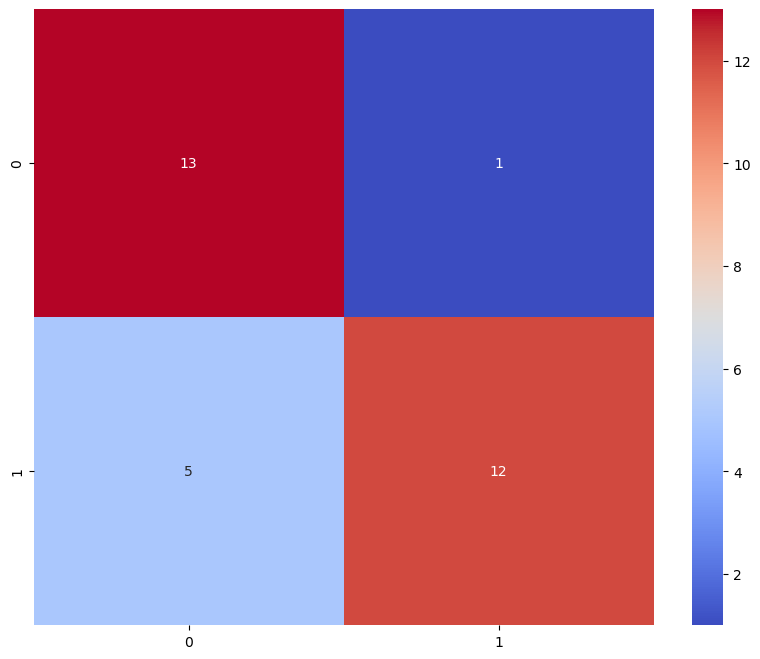

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, cmap='coolwarm')
plt.show()

**Final Task: A patient with the following features has come into the medical office:**

    age          48.0
    sex           0.0
    cp            2.0
    trestbps    130.0
    chol        275.0
    fbs           0.0
    restecg       1.0
    thalach     139.0
    exang         0.0
    oldpeak       0.2
    slope         2.0
    ca            0.0
    thal          2.0

**TASK: What does your model predict for this patient? Do they have heart disease? How "sure" is your model of this prediction?**

*For convience, we created an array of the features for the patient above*

In [50]:
patient_data = pd.DataFrame([{
    'age': 48.0,
    'sex': 0.0,
    'cp': 2.0,
    'trestbps': 130.0,
    'chol': 275.0,
    'fbs': 0.0,
    'restecg': 1.0,
    'thalach': 139.0,
    'exang': 0.0,
    'oldpeak': 0.2,
    'slope': 2.0,
    'ca': 0.0,
    'thal': 2.0
}])

In [52]:
# Scale using the already-fitted scaler
new_patient_scaled = scaler.transform(patient_data)

# Predict
prediction = nb_model.predict(new_patient_scaled)
prediction_proba = nb_model.predict_proba(new_patient_scaled)

print("Predicted class:", prediction[0])
print("Prediction probabilities:", prediction_proba[0])

Predicted class: 1
Prediction probabilities: [5.90831907e-04 9.99409168e-01]


In [53]:
# According to the results shown, we can see that the model predicted that the patient is diagnozed with the heart problems
# The probability is very high that he is sick